In [1]:
# Base Paths
base_path = r'D:\Dsoft\Projects\ML\data\student_health_risk\data'
train_file = base_path + r"\train.csv"
test_file = base_path + r"\test.csv"

In [2]:
import pandas as pd
train = pd.read_csv(train_file)

In [ ]:
TARGET = 'health_condition'


In [39]:
categorical_cols = ['physical_activity_level','sleep_quality', 'smoking_alcohol', 'gender', 'stress_level', 'diet_type']
numerical_cols = ['water_intake', 'exercise_duration', 'step_count', 'calorie_expenditure', 'bmi', 'heart_rate', 'sleep_duration']
train

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


In [41]:
for i in categorical_cols:
    print('-'*25)
    print(train[i].value_counts())

-------------------------
physical_activity_level
moderate     221041
sedentary    219784
active       212642
Name: count, dtype: int64
-------------------------
sleep_quality
average    213948
poor       212166
good       205643
Name: count, dtype: int64
-------------------------
smoking_alcohol
yes           223730
no            219791
occasional    217985
Name: count, dtype: int64
-------------------------
gender
male      237756
female    224016
other     206943
Name: count, dtype: int64
-------------------------
stress_level
medium    261819
high      177750
low       167708
Name: count, dtype: int64
-------------------------
diet_type
veg         231432
balanced    226888
non-veg     224867
Name: count, dtype: int64


In [63]:
TARGET_MAP: dict = {
    'fit': 2,
    'unhealthy': 1,
    'at-risk': 0
}
train[TARGET].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

In [ ]:
# import warnings
# warnings.filterwarnings(action='ignore')

In [51]:
for i in train.columns:
    xx = train[i].isna().value_counts()
    # print('-'*25)
    # print(i)
    if len(xx) > 1:
        print(f"{i}, ':','Percentage:', {100 -(100 * xx[0]/(xx[1] + xx[0]))} %", )
    else:
        print(f'{i} : 0 % Missing')

id : 0 % Missing
health_condition : 0 % Missing
sleep_duration, ':','Percentage:', 11.012943276799476 %
heart_rate, ':','Percentage:', 1.1350726284183992 %
bmi, ':','Percentage:', 2.013946047460607 %
calorie_expenditure, ':','Percentage:', 7.658878287986454 %
step_count, ':','Percentage:', 2.0165544104520023 %
exercise_duration, ':','Percentage:', 1.000017389086608 %
water_intake, ':','Percentage:', 6.300210987584194 %
diet_type, ':','Percentage:', 1.000017389086608 %
stress_level, ':','Percentage:', 12.00006375998423 %
sleep_quality, ':','Percentage:', 8.452690091698443 %
physical_activity_level, ':','Percentage:', 5.306714505976046 %
smoking_alcohol, ':','Percentage:', 4.1417906122117785 %
gender, ':','Percentage:', 3.097141234161441 %


In [ ]:
train.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [32]:
for i in train.columns:
    xx = train[i].isna().value_counts()
    print('-'*25)
    # print(i)
    if len(xx) > 1:
        print(xx)
        print('Percentage:',100 * xx[0]/(xx[1] + xx[0]))

-------------------------
-------------------------
-------------------------
sleep_duration
False    614089
True      75999
Name: count, dtype: int64
Percentage: 88.98705672320052
-------------------------
heart_rate
False    682255
True       7833
Name: count, dtype: int64
Percentage: 98.8649273715816
-------------------------
bmi
False    676190
True      13898
Name: count, dtype: int64
Percentage: 97.9860539525394
-------------------------
calorie_expenditure
False    637235
True      52853
Name: count, dtype: int64
Percentage: 92.34112171201355
-------------------------
step_count
False    676172
True      13916
Name: count, dtype: int64
Percentage: 97.983445589548
-------------------------
exercise_duration
False    683187
True       6901
Name: count, dtype: int64
Percentage: 98.99998261091339
-------------------------
water_intake
False    646611
True      43477
Name: count, dtype: int64
Percentage: 93.6997890124158
-------------------------
diet_type
False    683187
True       

C:\Users\16yas\AppData\Local\Temp\ipykernel_5488\714537227.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Percentage:',100 * xx[0]/(xx[1] + xx[0]))


In [37]:
train.drop(columns = ['id']).describe()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [ ]:
train[TARGET].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

<Axes: >

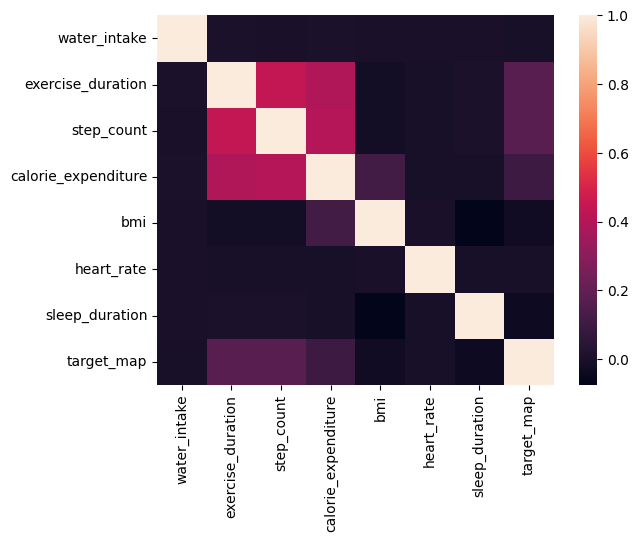

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
train['target_map'] = train[TARGET].map(TARGET_MAP)
sns.heatmap(train[numerical_cols + ['target_map']].corr())

In [65]:
train.isna().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
target_map                     0
dtype: int64

In [ ]:
train = pd.read_csv(train_file)
test = pd.read_csv(test_file)

In [86]:
test

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295748,985836,7.13,77.5,22.20,2221.0,13981.0,65.6,2.17,balanced,low,average,active,occasional,other
295749,985837,6.25,69.5,20.93,2242.0,2370.0,23.6,1.98,balanced,NaN,average,moderate,yes,female
295750,985838,NaN,77.0,23.62,2111.0,7647.0,25.1,2.18,veg,high,average,sedentary,no,other
295751,985839,7.25,66.3,21.47,2009.0,4672.0,25.1,2.02,veg,high,poor,moderate,no,female


In [90]:
train.describe(include='all')

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
count,690088.00000,690088.000000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000,683187,607277,631757,653467,661506,668715
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3,3,3,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,veg,medium,average,moderate,yes,male
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,231432,261819,213948,221041,223730,237756
mean,345043.50000,0.199004,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542,NaN,NaN,NaN,NaN,NaN,NaN
std,199211.39062,0.524174,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489,NaN,NaN,NaN,NaN,NaN,NaN
min,0.00000,0.000000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000,NaN,NaN,NaN,NaN,NaN,NaN
25%,172521.75000,0.000000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000,NaN,NaN,NaN,NaN,NaN,NaN
50%,345043.50000,0.000000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000,NaN,NaN,NaN,NaN,NaN,NaN
75%,517565.25000,0.000000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
import sweetviz as sv


# train[TARGET] = train[TARGET].map(TARGET_MAP)

# Compare train and test sets relative to a target variable
my_report = sv.compare([train, "Training Data"], [test, "Test Data"])
my_report.show_html("report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [91]:
df = train.copy()

In [93]:
df = df.dropna()

In [94]:
df

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,1,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,0,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,1,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,1,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
5,5,0,5.11,82.8,24.43,2290.0,2134.0,29.2,2.02,veg,low,poor,sedentary,occasional,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690079,690079,0,7.89,90.9,21.04,2608.0,12226.0,53.5,2.38,balanced,medium,good,moderate,yes,other
690080,690080,0,6.20,58.2,25.78,1490.0,1441.0,12.8,1.81,veg,low,average,sedentary,occasional,male
690081,690081,0,7.02,79.2,23.35,2314.0,8881.0,45.3,1.77,balanced,medium,good,moderate,no,other
690084,690084,0,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male


<Axes: >

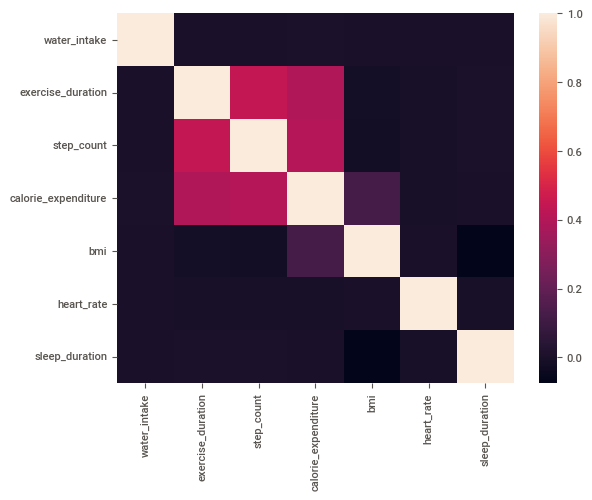

In [98]:
sns.heatmap(df[numerical_cols].corr())

In [103]:
plt.figure(figsize=(20, 30))
for j,i in enumerate(numerical_cols):
    plt.subplot(j)
    sns.boxplot(df[i])
plt.show()

ValueError: Single argument to subplot must be a three-digit integer, not 0

<Figure size 2000x3000 with 0 Axes>